In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pahdehrek/names4makemore/names.txt


In [2]:
file = open('/kaggle/input/datasets/pahdehrek/names4makemore/names.txt','r')
words = file.read().splitlines()

b = {}
for word in words:
    transformed = ['<S>'] + list(word) + ['<E>']
    for ch1,ch2 in zip(transformed,transformed[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1
sorted(b.items(), key = lambda kv: kv[1], reverse = True)[:5]


[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983)]

In [3]:
N = torch.zeros((27,27),dtype=torch.int32)

# N

In [4]:
chars = sorted(list(set(''.join(words))))
s_to_i = {s:i+1 for i,s in enumerate(chars)}
s_to_i['.'] = 0
i_to_s = {i:s for s,i in s_to_i.items()}
i_to_s

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

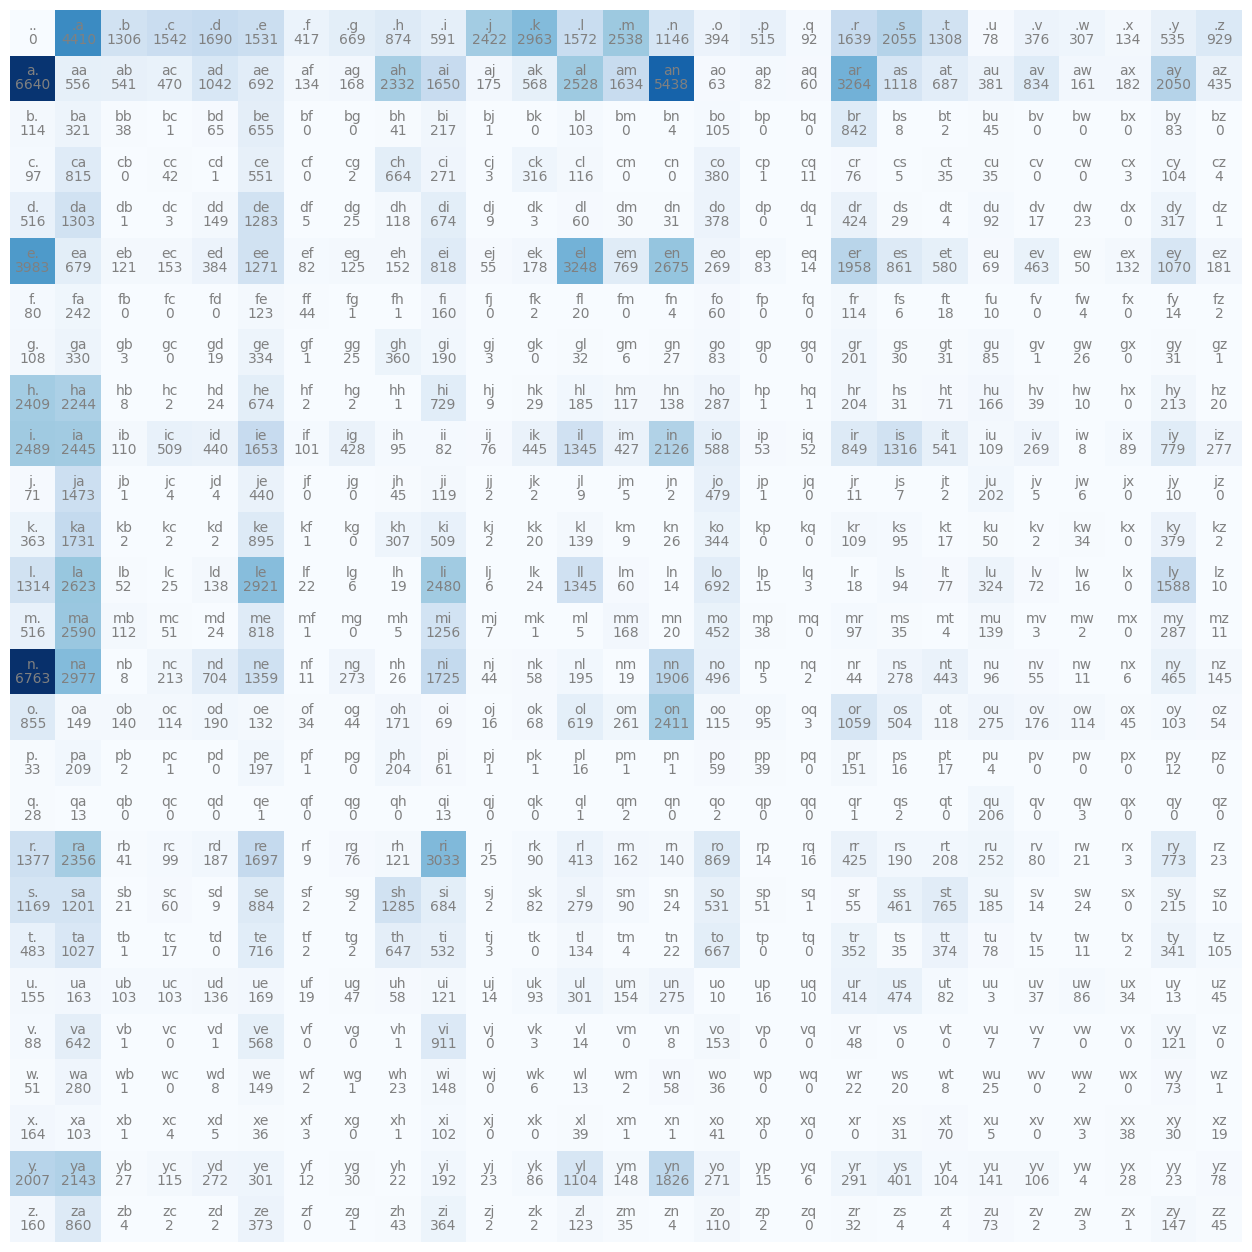

In [5]:
for w in words:
    transformed = '.'+w+'.'
    for ch1,ch2 in zip(transformed,transformed[1:]):
        i_ch1 = s_to_i[ch1]
        i_ch2 = s_to_i[ch2]
        N[(i_ch1,i_ch2)] += 1

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        ch_str = i_to_s[i] + i_to_s[j]
        plt.text(j, i, ch_str, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');
        

In [6]:
# g = torch.Generator().manual_seed(23428877)
# p = N[0]
# p = p/p.sum()

# ix = torch.multinomial(p,num_samples=1,replacement=True, generator = g).item()
# i_to_s[ix]


In [7]:
# torch.multinomial(p,num_samples=20,replacement=True)

In [8]:
# N.sum(0,keepdims=True)
P = (N+1).float() # +1 to smoothen the data so that my loss doesnt go to infinity lmao
P /= P.sum(1,keepdims=True)

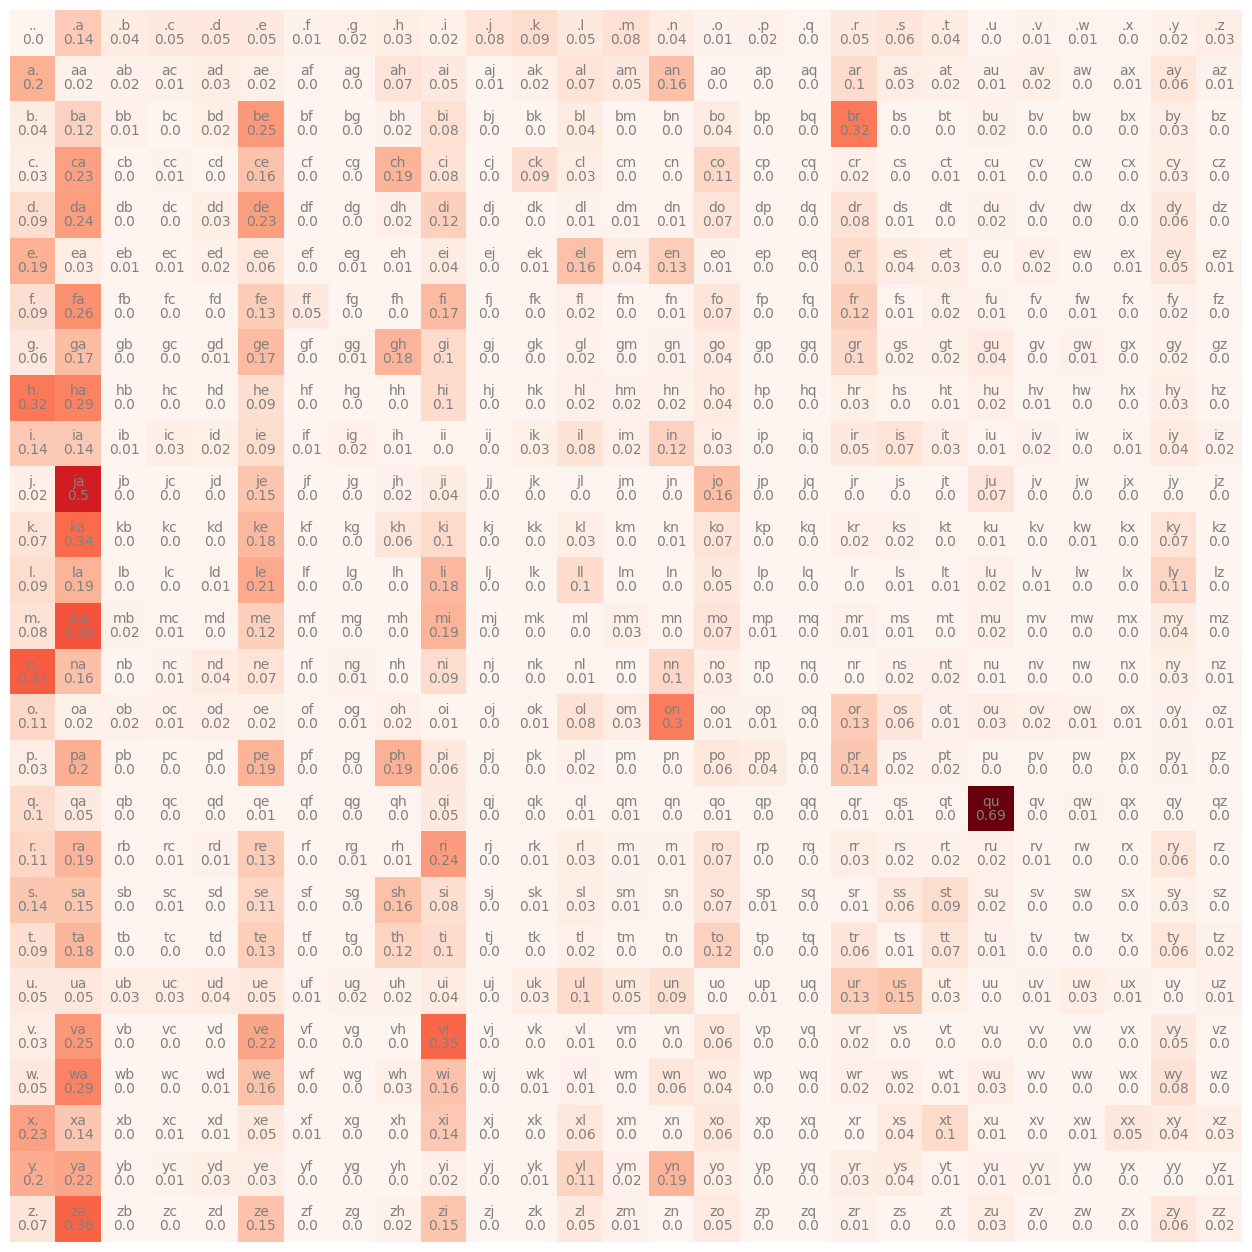

In [9]:
plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Reds')
for i in range(27):
    for j in range(27):
        ch_str = i_to_s[i] + i_to_s[j]
        plt.text(j, i, ch_str, ha="center", va="bottom", color='gray')
        plt.text(j, i, round(P[i, j].item(),2), ha="center", va="top", color='gray')
plt.axis('off');

In [10]:
g = torch.Generator().manual_seed(123678)
ix = 0
for _ in range(5):
    out=[]
    while True:
        p = P[ix]
        # p = N[ix].float()
        # p = p/p.sum()
        ix = torch.multinomial(p,num_samples=1, replacement=True, generator = g).item()
        out.append(i_to_s[ix])
        if ix == 0:
            break
    
    print(''.join(out))

mayli.
parvysitoberr.
jimi.
cannoreeles.
beeto.


In [11]:
log_likelihood = 0
n = 0

for w in words[:1]:
# for w in ['yanna']:
    transformed = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(transformed,transformed[1:]):
        ix1 = s_to_i[ch1]
        ix2 = s_to_i[ch2]
        log_prob = torch.log(P[ix1,ix2])
        n += 1
        log_likelihood += log_prob
        print(f'{ch1}{ch2} {P[ix1,ix2]:.3f} {log_prob:.3f}' )

print(f'{log_likelihood=}')
nll = -log_likelihood
mean_nll = nll/n
print(f'{mean_nll=}')

.e 0.048 -3.041
em 0.038 -3.279
mm 0.025 -3.675
ma 0.389 -0.945
a. 0.196 -1.631
log_likelihood=tensor(-12.5716)
mean_nll=tensor(2.5143)


In [12]:
xs = []
ys = []

for w in words[:1]:
    transformed = ['.']+list(w)+['.']
    for ch1,ch2 in zip(transformed,transformed[1:]):
        ix1 = s_to_i[ch1]
        ix2 = s_to_i[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [13]:
ys

tensor([ 5, 13, 13,  1,  0])

In [14]:
import torch.nn.functional as F
x_enc = F.one_hot(xs, num_classes=27).float()
print(x_enc.shape)
print(x_enc.dtype)

torch.Size([5, 27])
torch.float32


In [15]:
W = torch.randn([27,27])
logits = x_enc @ W
print(x_enc.shape)
print(W.shape)
logits.shape

torch.Size([5, 27])
torch.Size([27, 27])


torch.Size([5, 27])

In [16]:
counts = logits.exp()
print(counts)
probs = counts/counts.sum(axis=1,keepdim=True)
print(probs[0].sum())
probs

tensor([[ 0.6326,  2.0973,  0.8495,  0.7511,  0.2992,  0.5349,  3.9943,  0.4438,
          1.6216,  0.3013,  5.4774,  0.9129,  1.2513,  1.7654,  0.4772,  0.6358,
          0.6223,  0.9526,  1.0393,  1.2458,  3.7017,  2.3996,  1.3451,  0.1959,
          0.6483,  0.6483,  1.0245],
        [15.0535,  1.0802,  1.8570,  2.0678,  1.4298,  0.7073,  1.1222,  1.4413,
          1.1648,  1.7305,  0.5023,  0.1961,  0.9526,  4.4537,  0.5506,  3.1803,
          1.4813,  0.7646,  0.7113,  2.0079,  4.1990,  0.5657,  0.5626,  2.6737,
          0.8895,  0.9240,  0.5113],
        [ 0.3942,  2.7300,  0.5622,  0.6385,  0.1561,  1.5468,  0.4606,  1.8963,
          1.3021,  0.3584,  1.1793,  1.0371,  0.1818,  1.5772,  0.4182,  0.2391,
          1.5592,  0.6421,  1.1911,  0.6708,  1.5308,  2.9718,  0.1569,  2.1842,
          0.9579,  2.1457,  0.6679],
        [ 0.3942,  2.7300,  0.5622,  0.6385,  0.1561,  1.5468,  0.4606,  1.8963,
          1.3021,  0.3584,  1.1793,  1.0371,  0.1818,  1.5772,  0.4182,  0.2391

tensor([[0.0176, 0.0585, 0.0237, 0.0209, 0.0083, 0.0149, 0.1114, 0.0124, 0.0452,
         0.0084, 0.1527, 0.0255, 0.0349, 0.0492, 0.0133, 0.0177, 0.0173, 0.0266,
         0.0290, 0.0347, 0.1032, 0.0669, 0.0375, 0.0055, 0.0181, 0.0181, 0.0286],
        [0.2852, 0.0205, 0.0352, 0.0392, 0.0271, 0.0134, 0.0213, 0.0273, 0.0221,
         0.0328, 0.0095, 0.0037, 0.0180, 0.0844, 0.0104, 0.0603, 0.0281, 0.0145,
         0.0135, 0.0380, 0.0796, 0.0107, 0.0107, 0.0507, 0.0169, 0.0175, 0.0097],
        [0.0134, 0.0930, 0.0192, 0.0218, 0.0053, 0.0527, 0.0157, 0.0646, 0.0444,
         0.0122, 0.0402, 0.0353, 0.0062, 0.0537, 0.0142, 0.0081, 0.0531, 0.0219,
         0.0406, 0.0229, 0.0521, 0.1012, 0.0053, 0.0744, 0.0326, 0.0731, 0.0228],
        [0.0134, 0.0930, 0.0192, 0.0218, 0.0053, 0.0527, 0.0157, 0.0646, 0.0444,
         0.0122, 0.0402, 0.0353, 0.0062, 0.0537, 0.0142, 0.0081, 0.0531, 0.0219,
         0.0406, 0.0229, 0.0521, 0.1012, 0.0053, 0.0744, 0.0326, 0.0731, 0.0228],
        [0.0414, 0.0164,

In [17]:
nlls = torch.zeros(5)

for i in range(5):
    x = xs[i].item()
    y = ys[i].item()

    print(f'character that we have: {x}  ({i_to_s[x]})')
    print(f'character that we are trying to predict {y} ({i_to_s[y]})')
    prob = probs[i,y]
    print(f'prob that we predict that *CORRECT* character: {prob.item()}')
    nll = -(torch.log(prob))
    print(f'negative log likelihood of that prob: {nll.item()}')
    nlls[i] = nll

print(f'\n\nMEAN of the nll is: {nlls.mean().item()}')
print('WE WANT TO LOWER THIS AS MUCH AS POSSIBLE')
print('DOING SO WILL INCREASE THE PROBABILITY OF THE CORRECT ANSWER!!!! yay')
print('WE LOWER THIS BY ADJUSTING THE WEIGHTSSSSSS (to the negative gradient)')

character that we have: 0  (.)
character that we are trying to predict 5 (e)
prob that we predict that *CORRECT* character: 0.014912774786353111
negative log likelihood of that prob: 4.205536842346191
character that we have: 5  (e)
character that we are trying to predict 13 (m)
prob that we predict that *CORRECT* character: 0.08437997847795486
negative log likelihood of that prob: 2.4724252223968506
character that we have: 13  (m)
character that we are trying to predict 13 (m)
prob that we predict that *CORRECT* character: 0.05372612550854683
negative log likelihood of that prob: 2.923855781555176
character that we have: 13  (m)
character that we are trying to predict 1 (a)
prob that we predict that *CORRECT* character: 0.09299535304307938
negative log likelihood of that prob: 2.3752057552337646
character that we have: 1  (a)
character that we are trying to predict 0 (.)
prob that we predict that *CORRECT* character: 0.04143892228603363
negative log likelihood of that prob: 3.183534622

In [18]:
xs.shape

torch.Size([5])

In [19]:
ys.shape

torch.Size([5])

In [20]:
g = torch.Generator().manual_seed(29734225)
W = torch.randn((27,27),generator=g, requires_grad = True)

In [21]:
xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W
counts = torch.exp(logits)
probs = counts / counts.sum(axis=1, keepdim=True)
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(4.7336, grad_fn=<NegBackward0>)

In [22]:
W.grad = None
loss.backward()

In [23]:
W.data += -0.1*W.grad

In [24]:
loss

tensor(4.7336, grad_fn=<NegBackward0>)

In [25]:
xs, ys = [],[]

for w in words:
    transformed = ['.']+list(w)+['.']
    for ch1,ch2 in zip(transformed,transformed[1:]):
        ix1 = s_to_i[ch1]
        ix2 = s_to_i[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
num

228146

In [26]:
n = 100
lossi = []
stepi = []


for i in range(n):
    xenc = F.one_hot(xs, num_classes = 27).float()
    logits = xenc @ W
    counts = torch.exp(logits)
    probs = counts / counts.sum(axis=1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()
    W.grad = None
    loss.backward()
    W.data += -10*W.grad

    lossi.append(loss.item())
    stepi.append(i)
    # print(loss.item())

# xenc = F.one_hot(xs, num_classes = 27).float()
# logits = xenc @ W
# counts = torch.exp(logits)
# probs = counts / counts.sum(axis=1, keepdim=True)
# loss = -probs[torch.arange(num), ys].log().mean()
# loss.backward()

print(loss)

tensor(2.5873, grad_fn=<AddBackward0>)


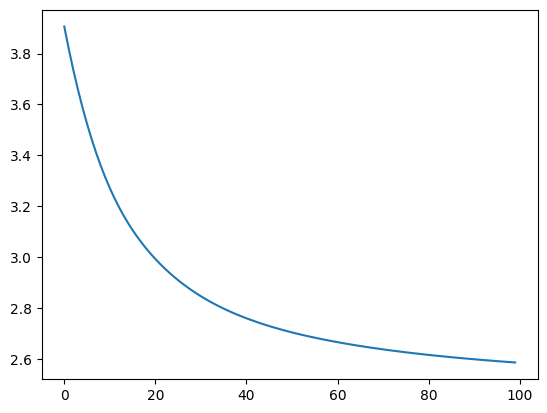

In [27]:
plt.plot(stepi,lossi)

In [28]:
g = torch.Generator().manual_seed(12378)

for _ in range(20):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]),num_classes=27).float()
        logits = xenc @ W
        counts = torch.exp(logits)
        p = counts/counts.sum(axis=1,keepdim=True)
        
        ix = torch.multinomial(p,num_samples=1,replacement=True,generator = g).item()
        out.append(i_to_s[ix])
        if ix == 0:
            break
    print(''.join(out))

p

ja.
dorueaharli.
ale.
dtharta.
erielar.
bch.
trijocka.
zhxgwqdaddie.
mdekzphanaticrinzx.
akmpli.
haniako.
lyny.
job.
nizqjs.
j.
jriahraktha.
nia.
amxxx.
wrlikoyla.
zpbellulxophagehri.


tensor([[0.1377, 0.1353, 0.0128, 0.0281, 0.0240, 0.0904, 0.0065, 0.0245, 0.0110,
         0.0102, 0.0116, 0.0250, 0.0723, 0.0229, 0.1171, 0.0280, 0.0043, 0.0101,
         0.0392, 0.0705, 0.0301, 0.0063, 0.0170, 0.0041, 0.0096, 0.0408, 0.0106]],
       grad_fn=<DivBackward0>)